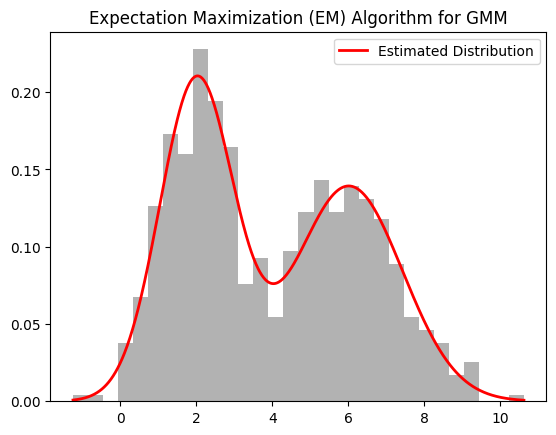

Estimated Means: [2.01031189 6.01305102]
Estimated Variances: [0.94892667 1.99057541]


In [ ]:
# NAME : KAUSHAL SHETE
# PRN : 20220802168
# BATCH : DS-1

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Generate synthetic data with two Gaussian distributions
np.random.seed(42)
n_samples = 300

# First Gaussian (mean=2, std=1)
data1 = np.random.normal(loc=2, scale=1, size=(n_samples, 1))

# Second Gaussian (mean=6, std=1.5)
data2 = np.random.normal(loc=6, scale=1.5, size=(n_samples, 1))

# Combine data
data = np.vstack((data1, data2))

# Fit Gaussian Mixture Model using EM algorithm
gmm = GaussianMixture(n_components=2, max_iter=100, random_state=42)
gmm.fit(data)

# Predict clusters
labels = gmm.predict(data)

# Plot results
plt.hist(data, bins=30, density=True, alpha=0.6, color='gray')
x = np.linspace(min(data), max(data), 1000)
pdf = np.exp(gmm.score_samples(x.reshape(-1, 1)))
plt.plot(x, pdf, color='red', lw=2, label="Estimated Distribution")
plt.title("Expectation Maximization (EM) Algorithm for GMM")
plt.legend()
plt.show()

# Print estimated means and covariances
print("Estimated Means:", gmm.means_.flatten())
print("Estimated Variances:", gmm.covariances_.flatten())


    With Dataset

Dataset Columns: Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
First 5 Rows:
         Price               Close                High                 Low  \
0      Ticker                TSLA                TSLA                TSLA   
1        Date                 NaN                 NaN                 NaN   
2  2010-06-29  1.5926669836044312  1.6666669845581055  1.1693329811096191   
3  2010-06-30  1.5886670351028442  2.0280001163482666   1.553333044052124   
4  2010-07-01  1.4639999866485596  1.7280000448226929  1.3513330221176147   

                 Open     Volume  
0                TSLA       TSLA  
1                 NaN        NaN  
2  1.2666670083999634  281494500  
3  1.7193330526351929  257806500  
4  1.6666669845581055  123282000  


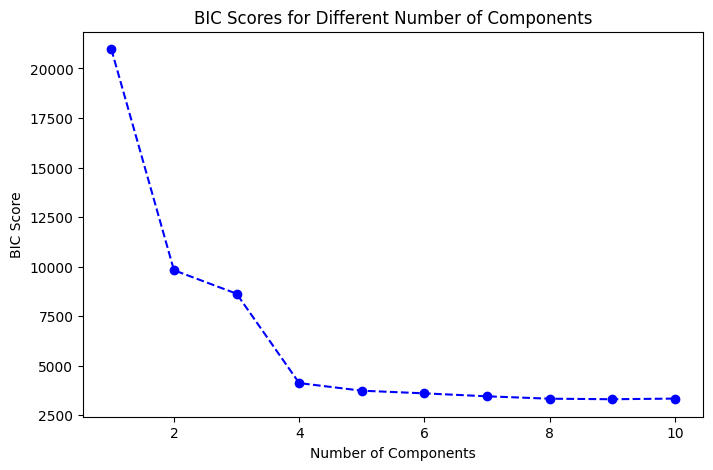

Optimal Number of Clusters: 9


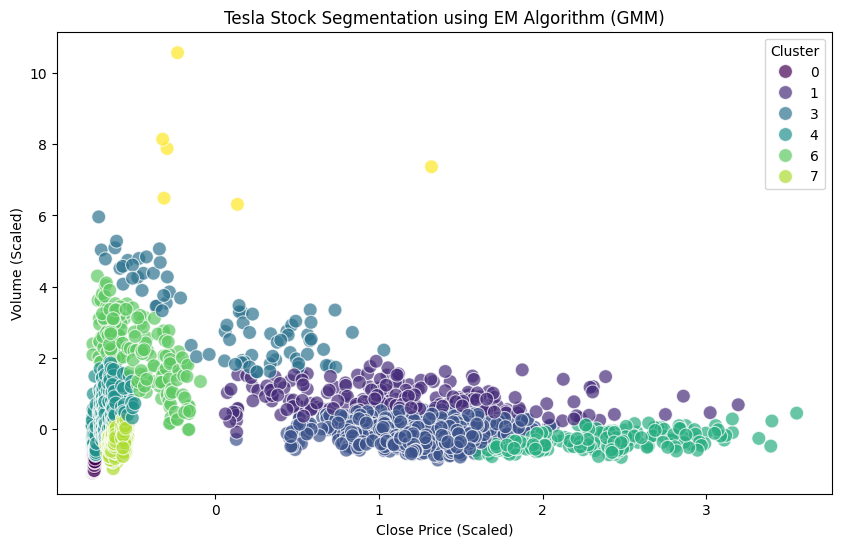

Cluster Centers (Estimated Means):
[[-0.74371172 -1.02075871]
 [ 1.13648414  0.64620575]
 [ 1.2285126  -0.0678824 ]
 [ 0.15958827  2.67079164]
 [-0.62882388  0.41960446]
 [ 2.21040676 -0.33815291]
 [-0.47092906  2.08062541]
 [-0.6048952  -0.32085862]
 [-0.10975407  6.62254348]]
Clustered dataset saved as 'Tesla_Stock_Clustered.csv'


In [ ]:
# NAME : KALPESH YASHWANT PATIL
# PRN : 20220802190
# BATCH : DS-1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Load the dataset
file_path = "C:/Users/asus/OneDrive/Desktop/tesla_stock_data_2000_2025.csv"
data = pd.read_csv(file_path)

# Display column names and first few rows
print("Dataset Columns:", data.columns)
print("First 5 Rows:\n", data.head())

# Convert column names to lowercase and remove leading/trailing spaces
data.columns = data.columns.str.strip().str.lower()

# Check if 'close' and 'volume' exist in the dataset
if 'close' not in data.columns or 'volume' not in data.columns:
    print("Error: Columns 'Close' and 'Volume' not found in dataset.")
    print("Available columns:", data.columns)
    exit()

# Convert 'close' and 'volume' to numeric, forcing errors to NaN
data['close'] = pd.to_numeric(data['close'], errors='coerce')
data['volume'] = pd.to_numeric(data['volume'], errors='coerce')

# Drop rows where 'Close' or 'Volume' could not be converted
data = data.dropna(subset=['close', 'volume'])

# Select relevant features
X = data[['close', 'volume']].values  # Convert to NumPy array

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using BIC
n_components = np.arange(1, 11)
models = [GaussianMixture(n_components=n, random_state=42).fit(X_scaled) for n in n_components]
bics = [model.bic(X_scaled) for model in models]

# Plot BIC scores
plt.figure(figsize=(8, 5))
plt.plot(n_components, bics, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for Different Number of Components')
plt.show()

# Select the model with the lowest BIC
optimal_n = n_components[np.argmin(bics)]
print(f"Optimal Number of Clusters: {optimal_n}")

# Apply Gaussian Mixture Model
gmm = GaussianMixture(n_components=optimal_n, random_state=42)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

# Add cluster labels to the dataset
data['cluster'] = labels

# Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette='viridis', s=100, alpha=0.7)
plt.xlabel('Close Price (Scaled)')
plt.ylabel('Volume (Scaled)')
plt.title('Tesla Stock Segmentation using EM Algorithm (GMM)')
plt.legend(title='Cluster')
plt.show()

# Print cluster means
print("Cluster Centers (Estimated Means):")
print(gmm.means_)

# Save clustered data
data.to_csv("Tesla_Stock_Clustered.csv", index=False)
print("Clustered dataset saved as 'Tesla_Stock_Clustered.csv'")
